In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.
Path to dataset files: /kaggle/input/student-performance-multiple-linear-regression


In [ ]:
import pandas as pd
df=pd.read_csv(f'{path}/Student_Performance.csv')
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer,LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# models
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [ ]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


<Axes: xlabel='Performance Index', ylabel='Count'>

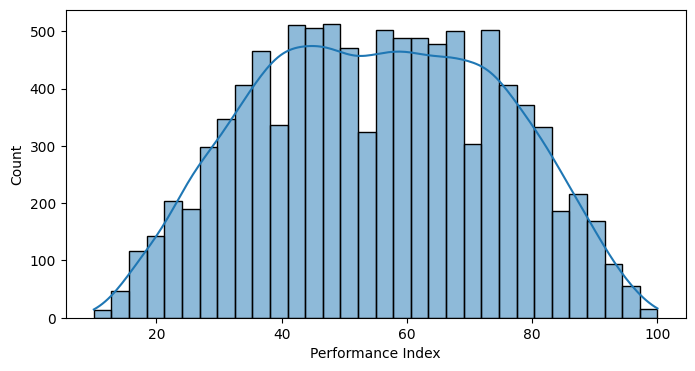

In [ ]:
df['Performance Index']
plt.figure(figsize=(8,4))
sns.histplot(df['Performance Index'],kde=True)

<Axes: >

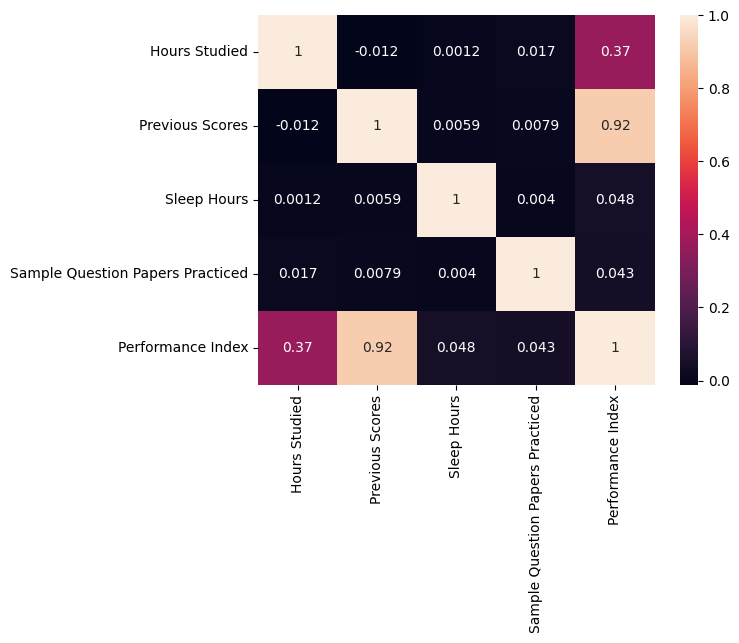

In [ ]:
# corr numerical Corr
num=df.select_dtypes(include=[np.number])
sns.heatmap(num.corr(),annot=True)

In [ ]:
x=df.drop('Performance Index',axis=1)
y=df['Performance Index']

In [ ]:
numerical_feature=x.select_dtypes(include=[np.number]).columns.tolist()
categorical_feature=['Extracurricular Activities']

In [ ]:
#Make 2 pipeline for numerical & categorical column
# Then combine it in one pipeline

In [ ]:
from types import SimpleNamespace
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.impute import SimpleImputer # Import SimpleImputer
# simple Pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])
numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('power', PowerTransformer()), ('scaler', StandardScaler())])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
# Combine preprocessors
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_feature),
    ('cat', categorical_transformer, categorical_feature)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('power', PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Hours Studied', 'Previous Scores',
                                  'Sleep Hours',
                                  'Sample Question Papers Practiced']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Extracurricular Activities'])])

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.18,random_state=42)

In [ ]:
models={
    'LinearRegression ': LinearRegression(),
    'Ridge':Ridge(random_state=42),
    'Lasso':Lasso(random_state=44),
    'Desicion Tree': DecisionTreeRegressor(max_depth=10),
    'Random_Forest': RandomForestRegressor(n_estimators=200),
    'GradientBoosting':GradientBoostingRegressor(n_estimators=200),
    'KNN':KNeighborsRegressor(),
    'SVR':SVR(kernel='rbf',C=1.0)

}

In [ ]:

# Evaluate all models
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({'Model': name, 'R2 Score': r2, 'MAE': mae, 'RMSE': rmse})

In [ ]:
results

[{'Model': 'LinearRegression ',
  'R2 Score': 0.9878252024061122,
  'MAE': 1.6916880890669608,
  'RMSE': np.float64(2.1261791522532034)},
 {'Model': 'Ridge',
  'R2 Score': 0.9878244037489788,
  'MAE': 1.691750729626434,
  'RMSE': np.float64(2.1262488889484588)},
 {'Model': 'Lasso',
  'R2 Score': 0.978700821509009,
  'MAE': 2.2173178326170744,
  'RMSE': np.float64(2.8122272170811264)},
 {'Model': 'Desicion Tree',
  'R2 Score': 0.9829408372787307,
  'MAE': 1.9706958522642546,
  'RMSE': np.float64(2.516794965094969)},
 {'Model': 'Random_Forest',
  'R2 Score': 0.98605871333598,
  'MAE': 1.8208673225308645,
  'RMSE': np.float64(2.27520434925346)},
 {'Model': 'GradientBoosting',
  'R2 Score': 0.9886521807954454,
  'MAE': 1.623309079980169,
  'RMSE': np.float64(2.052698592496561)},
 {'Model': 'KNN',
  'R2 Score': 0.9769177098632978,
  'MAE': 2.3644444444444446,
  'RMSE': np.float64(2.9275776866056193)},
 {'Model': 'SVR',
  'R2 Score': 0.9859736712416513,
  'MAE': 1.787946498001933,
  'RMSE': 

In [ ]:
# Results table
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("\nModel Performance Comparison:\n")
print(results_df)


Model Performance Comparison:

               Model  R2 Score       MAE      RMSE
5   GradientBoosting  0.988652  1.623309  2.052699
0  LinearRegression   0.987825  1.691688  2.126179
1              Ridge  0.987824  1.691751  2.126249
4      Random_Forest  0.986059  1.820867  2.275204
7                SVR  0.985974  1.787946  2.282133
3      Desicion Tree  0.982941  1.970696  2.516795
2              Lasso  0.978701  2.217318  2.812227
6                KNN  0.976918  2.364444  2.927578


In [ ]:
# Best model selection
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n  Best Model: {best_model_name}")


  Best Model: GradientBoosting


In [ ]:
# Refit best model
final_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                             ('model', best_model)])
final_pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Hours Studied',
                                                   'Previous Scores',
                                                   'Sleep Hours',
                                                   'Sample Question Papers '
                                                   'Practiced']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Extracurricular '
                                                   'Activities'])])),
                ('model', GradientBoostingRegressor(n_estimators=200))])

In [ ]:
# Predictions
final_pred = final_pipe.predict(x_test)
print("\nFinal R2 Score:", r2_score(y_test, final_pred))


Final R2 Score: 0.9886521807954454


In [ ]:
import pickle
# 4--- Save model as pickle file ---
with open('model.pkl', 'wb') as file:   # 'wb' means write-binary mode
    pickle.dump(best_model, file)